In [33]:
import pandas as pd
import numpy as np
import seaborn as sns

In [34]:
df=pd.read_csv(r"data\Titanic-Dataset.csv")

In [35]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [37]:
(df.isna().sum()/df.shape[0])*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

<Axes: ylabel='Age'>

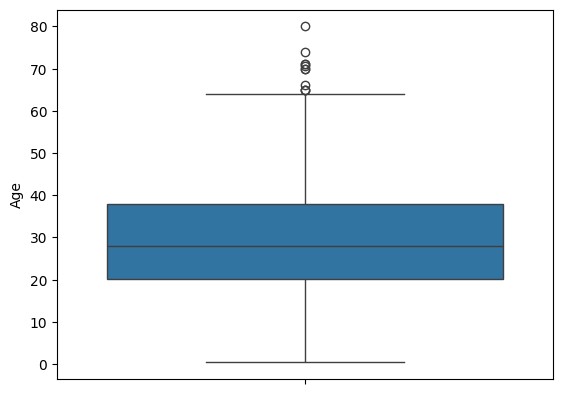

In [38]:
sns.boxplot(df["Age"])

In [39]:
df.Age.fillna(df["Age"].median(),inplace=True)
df.Embarked.fillna(df["Embarked"].mode()[0],inplace=True)


C:\Users\CM617YH\AppData\Local\Temp\ipykernel_4112\1030691913.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Age.fillna(df["Age"].median(),inplace=True)
C:\Users\CM617YH\AppData\Local\Temp\ipykernel_4112\1030691913.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [40]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [41]:
df.drop(["Cabin","Name","Ticket"],axis=1,inplace=True)

In [42]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,28.0,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [43]:
df=pd.get_dummies(df,columns=["Sex","Embarked"],drop_first=True,dtype=int)

In [44]:
df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,1,0,1
887,888,1,1,19.0,0,0,30.0000,0,0,1
888,889,0,3,28.0,1,2,23.4500,0,0,1
889,890,1,1,26.0,0,0,30.0000,1,0,0


In [45]:
df["family_size"]=df["SibSp"]+df["Parch"]

In [46]:
df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,family_size
0,1,0,3,22.0,1,0,7.2500,1,0,1,1
1,2,1,1,38.0,1,0,71.2833,0,0,0,1
2,3,1,3,26.0,0,0,7.9250,0,0,1,0
3,4,1,1,35.0,1,0,53.1000,0,0,1,1
4,5,0,3,35.0,0,0,8.0500,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,1,0,1,0
887,888,1,1,19.0,0,0,30.0000,0,0,1,0
888,889,0,3,28.0,1,2,23.4500,0,0,1,3
889,890,1,1,26.0,0,0,30.0000,1,0,0,0


In [47]:
df.drop(["SibSp","Parch"],axis=1,inplace=True)

In [48]:
df

,PassengerId,Survived,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S,family_size
0,1,0,3,22.0,7.2500,1,0,1,1
1,2,1,1,38.0,71.2833,0,0,0,1
2,3,1,3,26.0,7.9250,0,0,1,0
3,4,1,1,35.0,53.1000,0,0,1,1
4,5,0,3,35.0,8.0500,1,0,1,0
...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,13.0000,1,0,1,0
887,888,1,1,19.0,30.0000,0,0,1,0
888,889,0,3,28.0,23.4500,0,0,1,3
889,890,1,1,26.0,30.0000,1,0,0,0


In [49]:
x=df.drop("Survived",axis=1)
y=df["Survived"]

In [50]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
Nb=GaussianNB()

In [21]:
Nb.fit(x_train,y_train)
pred=Nb.predict(x_test)

In [22]:
from sklearn.metrics import classification_report,confusion_matrix

In [23]:
print(confusion_matrix(y_test,pred))

[[85 20]
 [20 54]]


In [24]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       105
           1       0.73      0.73      0.73        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [25]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
pred_lr=lr.predict(x_test)
print(confusion_matrix(y_test,pred_lr))
print(classification_report(y_test,pred_lr))

[[90 15]
 [20 54]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



C:\Users\CM617YH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
from sklearn.svm import SVC
svc=SVC()   
svc.fit(x_train,y_train)
pred_svc=svc.predict(x_test)    
print(confusion_matrix(y_test,pred_svc))
print(classification_report(y_test,pred_svc))

[[103   2]
 [ 70   4]]
              precision    recall  f1-score   support

           0       0.60      0.98      0.74       105
           1       0.67      0.05      0.10        74

    accuracy                           0.60       179
   macro avg       0.63      0.52      0.42       179
weighted avg       0.62      0.60      0.48       179



In [ ]:
svc=SVC(kernel="poly",C=10,gamma="auto")   
svc.fit(x_train,y_train)
pred_svc=svc.predict(x_test)    
print(confusion_matrix(y_test,pred_svc))
print(classification_report(y_test,pred_svc))

In [27]:
para={"C":[0.1,1,10,100],"gamma":[1,0.1,0.01,0.001],"kernel":["rbf"]}
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(SVC(),param_grid=para,refit=True,verbose=3)
grid.fit(x_train,y_train)
print(grid.best_estimator_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.622 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.622 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.627 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.627 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.620 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.622 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.622 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.627 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.627 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.620 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.622 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf;

In [28]:
model=SVC(C=10, gamma=0.001,kernel="rbf")
model.fit(x_train,y_train)
pred=model.predict(x_test)
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

[[91 14]
 [53 21]]
              precision    recall  f1-score   support

           0       0.63      0.87      0.73       105
           1       0.60      0.28      0.39        74

    accuracy                           0.63       179
   macro avg       0.62      0.58      0.56       179
weighted avg       0.62      0.63      0.59       179



In [29]:
from sklearn.model_selection import KFold, cross_val_score

import numpy as np



# K-Fold Cross Validation
k = 5  
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize the RandomForestClassifier model
svc = SVC(kernel='rbf', C=10, gamma=0.1)

# Perform Cross Validation
scores = cross_val_score(svc, x, y, cv=kf, scoring='accuracy')

print(f"Accuracy for each fold: {scores}")

average_accuracy = np.mean(scores) 
print(f"Average Accuracy: {average_accuracy:.2f}")

Accuracy for each fold: [0.59217877 0.63483146 0.58988764 0.59550562 0.61797753]
Average Accuracy: 0.61


In [32]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

kf = KFold(n_splits=k, shuffle=True, random_state=42)

pipe = Pipeline([
    ('model', LogisticRegression())
])

param_grid = [
    {'model': [LogisticRegression()]},
    {'model': [SVC()], 'model__C': [10], 'model__gamma': [0.001]},
    {'model': [GaussianNB()]}
]

grid = GridSearchCV(pipe, param_grid, cv=kf, refit=True, verbose=3)
grid.fit(x, y)

print("Best model:", grid.best_estimator_)
print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV 1/5] END ........model=LogisticRegression();, score=0.810 total time=   0.0s
[CV 2/5] END ........model=LogisticRegression();, score=0.775 total time=   0.0s
[CV 3/5] END ........model=LogisticRegression();, score=0.826 total time=   0.0s


C:\Users\CM617YH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\CM617YH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase 

[CV 4/5] END ........model=LogisticRegression();, score=0.758 total time=   0.0s
[CV 5/5] END ........model=LogisticRegression();, score=0.775 total time=   0.0s
[CV 1/5] END model=SVC(), model__C=10, model__gamma=0.001;, score=0.626 total time=   0.0s
[CV 2/5] END model=SVC(), model__C=10, model__gamma=0.001;, score=0.635 total time=   0.0s
[CV 3/5] END model=SVC(), model__C=10, model__gamma=0.001;, score=0.674 total time=   0.0s
[CV 4/5] END model=SVC(), model__C=10, model__gamma=0.001;, score=0.590 total time=   0.0s


C:\Users\CM617YH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV 5/5] END model=SVC(), model__C=10, model__gamma=0.001;, score=0.551 total time=   0.0s
[CV 1/5] END ................model=GaussianNB();, score=0.777 total time=   0.0s
[CV 2/5] END ................model=GaussianNB();, score=0.809 total time=   0.0s
[CV 3/5] END ................model=GaussianNB();, score=0.826 total time=   0.0s
[CV 4/5] END ................model=GaussianNB();, score=0.753 total time=   0.0s
[CV 5/5] END ................model=GaussianNB();, score=0.775 total time=   0.0s
Best model: Pipeline(steps=[('model', LogisticRegression())])
Best params: {'model': LogisticRegression()}
Best score: 0.788977465319189


C:\Users\CM617YH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier




In [53]:
dc=DecisionTreeClassifier()
dc.fit(x_train,y_train)
pred=dc.predict(x_test)
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))


[[78 27]
 [25 49]]
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       105
           1       0.64      0.66      0.65        74

    accuracy                           0.71       179
   macro avg       0.70      0.70      0.70       179
weighted avg       0.71      0.71      0.71       179



In [56]:
print(dc.score(x_train,y_train))
print(dc.score(x_test,y_test))

1.0
0.7094972067039106


In [59]:
dc=DecisionTreeClassifier(max_depth=5,max_features=6,criterion="entropy")
dc.fit(x_train,y_train)
pred=dc.predict(x_test)
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

[[95 10]
 [26 48]]
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



In [60]:
print(dc.score(x_train,y_train))
print(dc.score(x_test,y_test))

0.8455056179775281
0.7988826815642458


In [61]:
dc=RandomForestClassifier(n_estimators=100,max_depth=5,max_features=6,criterion="entropy")
dc.fit(x_train,y_train)
pred=dc.predict(x_test)
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

[[93 12]
 [23 51]]
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [62]:
print(dc.score(x_train,y_train))
print(dc.score(x_test,y_test))

0.8665730337078652
0.8044692737430168
